In [1]:
!pip install datasets tensorflow scikit-learn

In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import classification_report, accuracy_score

In [3]:
dataset = load_dataset("sh0416/ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

X_train = [title + " " + description for title, description in zip(train_data["title"], train_data["description"])]
y_train = np.array(train_data["label"]) - 1 # Adjust labels to be 0-indexed

X_test = [title + " " + description for title, description in zip(test_data["title"], test_data["description"])]
y_test = np.array(test_data["label"]) - 1 # Adjust labels to be 0-indexed

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training Samples: 120000
Testing Samples: 7600


In [4]:
print(train_data.column_names)

['label', 'title', 'description']


In [5]:
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [6]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

In [7]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train_pad,
    np.array(y_train),
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.2701 - loss: 1.3819 - val_accuracy: 0.3077 - val_loss: 1.3593
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 75ms/step - accuracy: 0.5100 - loss: 1.1614 - val_accuracy: 0.4925 - val_loss: 1.1786
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step - accuracy: 0.5644 - loss: 1.0662 - val_accuracy: 0.5473 - val_loss: 1.1049
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step - accuracy: 0.6240 - loss: 0.9468 - val_accuracy: 0.6019 - val_loss: 0.9971
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step - accuracy: 0.6573 - loss: 0.8794 - val_accuracy: 0.6149 - val_loss: 0.9793


In [10]:
loss, accuracy = model.evaluate(
    X_test_pad,
    np.array(y_test) # Labels are already 0-indexed (0, 1, 2, 3) from hQh6YOYH_AFz
)

print("Test Accuracy:", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6395 - loss: 0.9406
Test Accuracy: 0.6394736766815186


In [11]:
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
))

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
              precision    recall  f1-score   support

       World       0.67      0.64      0.65      1900
      Sports       0.66      0.78      0.71      1900
    Business       0.66      0.50      0.57      1900
    Sci/Tech       0.58      0.64      0.61      1900

    accuracy                           0.64      7600
   macro avg       0.64      0.64      0.64      7600
weighted avg       0.64      0.64      0.64      7600



In [12]:
sample_news = [
    "India won the cricket series against Australia.",
    "Stock market gains after positive economic reports.",
    "Scientists develop a new AI-powered healthcare system."
]

sample_seq = tokenizer.texts_to_sequences(sample_news)


In [13]:
sample_pad = pad_sequences(
    sample_seq,
    maxlen=max_length,
    padding='post'
)

predictions = model.predict(sample_pad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


In [14]:
categories = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

for news, pred in zip(sample_news, predictions):
    print(news)
    print("Category:", categories[np.argmax(pred)])
    print()

India won the cricket series against Australia.
Category: World

Stock market gains after positive economic reports.
Category: Business

Scientists develop a new AI-powered healthcare system.
Category: Sci/Tech



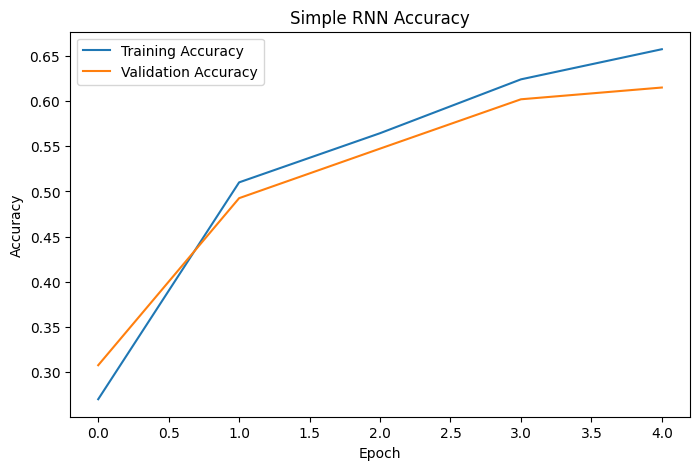

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN Accuracy")
plt.legend()
plt.show()